# Exploratory Data Analysis (EDA)
## Rx Drug Marketing Mix Modeling (MMIX)

### Business Context

Pharmaceutical firms compete within therapeutic classes, where multiple brands seek to influence prescriptions through two primary channels:

- **Detailing**: physician-targeted promotion
- **DTCA**: direct-to-consumer advertising

The commercial mechanism is:

> Marketing investment → influences physicians and patients → drives prescriptions → generates sales

### Business Objective

The goal of this analysis is to understand how marketing investments translate into sales outcomes across brands and therapeutic classes, and to identify patterns that should guide model design and budget decisions.

### Core Business Questions

1. Which brands dominate portfolio revenue, and how concentrated is the portfolio?
2. How has portfolio performance evolved over time?
3. How are detailing and Direct-to-Consumer Ads (DTCA) budgets allocated across brands and classes?
4. Which channel appears more efficient before formal modeling?
5. Is there evidence of diminishing returns to marketing spend?
6. Do classes and brands differ in baseline sales and marketing sensitivity?
7. Are there structurally different marketing regimes, especially around zero Direct-to-Consumer Ads (DTCA)?
8. What does the panel structure imply for modeling and validation?

### Scope of Analysis
This review encompasses an 11-year historical dataset, capturing the following parameters:
* Observation Period: 2013–2024
* Therapeutic Classes: PPI (Proton Pump Inhibitors), SSRI (Antidepressants), Statin (Cholesterol)
* Portfolio Size: 22 distinct brands
* Key Metrics Evaluated:
    * Top-line Sales in Billions of Dollars
    * Physician Detailing Spend in Millions of Dollars
    * Direct-to-Consumer Advertising (DTCA) Spend ($ Millions)

In [240]:
print("\n[EDA] Importing libraries...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("[EDA] Libraries loaded successfully.")


[EDA] Importing libraries...
[EDA] Libraries loaded successfully.


In [241]:
print("\n[EDA] Loading dataset and standardizing column names...")

df = pd.read_excel("data/MMM_Drug_Data.xlsx")

df = df.rename(columns={
    "Class": "class",
    "Agent": "agent",
    "Year": "year",
    "Detailing": "detailing",
    "Direct-to-Consumer Advertising (DTCA)": "direct_to_consumer_ad",
    "Actual Sales": "actual_sales"
})

print("[EDA] Dataset loaded successfully.")
display(df.head())


[EDA] Loading dataset and standardizing column names...
[EDA] Dataset loaded successfully.


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600


In [242]:
print("\n[EDA] Running initial data checks...")

print("Shape:", df.shape)

print("\nColumn types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nYears covered:", df["year"].min(), "to", df["year"].max())
print("Number of classes:", df["class"].nunique())
print("Number of agents:", df["agent"].nunique())

print("\n[Business Insight]")
print("The dataset covers 12 years (2013-2024), 22 agents (brands), and 3 therapeutic classes")
print("PPI (Proton Pump Inhibitors), SSRI (Antidepressants), Statin (Cholesterol) classes have zero missing values.")
print("This gives sufficient depth to evaluate marketing effectiveness at both the agent (brand) and class level.")


[EDA] Running initial data checks...
Shape: (207, 6)

Column types:


,dtype
class,str
agent,str
year,int64
detailing,float64
direct_to_consumer_ad,float64
actual_sales,float64



Missing values:


,missing_count
class,0
agent,0
year,0
detailing,0
direct_to_consumer_ad,0
actual_sales,0



Years covered: 2013 to 2024
Number of classes: 3
Number of agents: 22

[Business Insight]
The dataset covers 12 years (2013-2024), 22 agents (brands), and 3 therapeutic classes
PPI (Proton Pump Inhibitors), SSRI (Antidepressants), Statin (Cholesterol) classes have zero missing values.
This gives sufficient depth to evaluate marketing effectiveness at both the agent (brand) and class level.


In [243]:
print("\n[EDA] Checking agent (brand) coverage across years...")

panel = pd.crosstab(df["agent"], df["year"])

n_agents = df["agent"].nunique()
n_years = df["year"].nunique()
expected_rows = n_agents * n_years
actual_rows = len(df)

print(f"Expected rows in a balanced panel: {expected_rows}")
print(f"Actual rows observed: {actual_rows}")
print(f"Missing agent-year combinations: {expected_rows - actual_rows}")

display(panel)

# Diagnostic only: checking if any agents (brands) appear in later years but not in earlier years.
# Time-based split is intentional: random splits leak future data into training.
# Final modeling split: Train 2013-2021, Validation 2022-2023, Test 2024.
test_agents = set(df[df["year"] >= 2023]["agent"].unique())
train_agents = set(df[df["year"] <= 2020]["agent"].unique())

print("\n[EDA] Checking if any agents (brands) appear in test years but not in training years...")
print(f"Brands in test period (2023-2024) with no data in training period (<=2020): {test_agents - train_agents or 'None'}")
print(f"Brands in training period (<=2020) with no data in test period (2023-2024): {train_agents - test_agents or 'None'}")

print("\n[Business Insight]")
print("Only 207 of 264 possible agent (brand)-year combinations exist. Five agents (brands) entered after 2016,")
print("and Pexeva only appears from 2021 (4 records). Historical trends for newer agents (brands) are shorter")
print("and less reliable for forecasting or head-to-head comparisons with agents (brands) that have 12 years of data.")
print("[Modeling Note] Time-based split: Train 2013-2021, Validation 2022-2023, Test 2024. Pexeva requires special handling.")


[EDA] Checking agent (brand) coverage across years...
Expected rows in a balanced panel: 264
Actual rows observed: 207
Missing agent-year combinations: 57


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
agent,,,,,,,,,,,,
Aciphex,0,0,0,1,1,1,1,1,1,1,1,1
Altoprev,0,0,0,0,0,0,1,1,1,1,1,1
Celexa,0,0,1,1,1,1,1,1,1,1,1,1
Crestor,0,0,0,0,0,0,0,1,1,1,1,1
Lescol,1,1,1,1,1,1,1,1,1,1,1,1
Lescol XL,0,0,0,0,1,1,1,1,1,1,1,1
Lexapro,0,0,0,0,0,0,1,1,1,1,1,1
Lipitor,0,1,1,1,1,1,1,1,1,1,1,1
Luvox,1,1,1,1,1,1,1,1,1,1,1,1



[EDA] Checking if any agents (brands) appear in test years but not in training years...
Brands in test period (2023-2024) with no data in training period (<=2020): {'  Pexeva'}
Brands in training period (<=2020) with no data in test period (2023-2024): None

[Business Insight]
Only 207 of 264 possible agent (brand)-year combinations exist. Five agents (brands) entered after 2016,
and Pexeva only appears from 2021 (4 records). Historical trends for newer agents (brands) are shorter
and less reliable for forecasting or head-to-head comparisons with agents (brands) that have 12 years of data.
[Modeling Note] Time-based split: Train 2013-2021, Validation 2022-2023, Test 2024. Pexeva requires special handling.


In [244]:
print("\n[EDA] Generating summary statistics for key commercial variables...")

summary = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].describe()

summary_readable = summary.copy()
summary_readable["actual_sales"] = summary["actual_sales"].apply(lambda x: f"${x:,.2f}B")
summary_readable["detailing"] = summary["detailing"].apply(lambda x: f"${x:,.2f}M")
summary_readable["direct_to_consumer_ad"] = summary["direct_to_consumer_ad"].apply(lambda x: f"${x:,.2f}M")

summary_readable = summary_readable.reset_index().rename(columns={"index": "Metric"})
display(summary_readable)

print("\n[Business Insight]")
print("Sales range from ~$0B to $63B; detailing from $0 to $243M; Direct-to-Consumer Ads (DTCA) from $0 to $240M.")
print("The median agent (brand) generates $7.5B with $45M detailing and $0 Direct-to-Consumer Ads (DTCA),")
print("meaning most agents (brands) do not advertise to consumers at all.")
print("A small number of high-revenue agents (brands) dominate the portfolio averages.")


[EDA] Generating summary statistics for key commercial variables...


,Metric,actual_sales,detailing,direct_to_consumer_ad
0,count,$207.00B,$207.00M,$207.00M
1,mean,$11.67B,$56.03M,$26.32M
2,std,$12.97B,$54.92M,$49.30M
3,min,$0.00B,$0.00M,$0.00M
4,25%,$0.99B,$3.86M,$0.00M
5,50%,$7.53B,$44.97M,$0.00M
6,75%,$19.61B,$85.12M,$39.36M
7,max,$63.22B,$243.33M,$240.35M



[Business Insight]
Sales range from ~$0B to $63B; detailing from $0 to $243M; Direct-to-Consumer Ads (DTCA) from $0 to $240M.
The median agent (brand) generates $7.5B with $45M detailing and $0 Direct-to-Consumer Ads (DTCA),
meaning most agents (brands) do not advertise to consumers at all.
A small number of high-revenue agents (brands) dominate the portfolio averages.


## 1. Revenue Concentration
A first strategic question is whether sales are diversified or concentrated in a few blockbuster brands.


[EDA] Ranking brands by average sales contribution...


,agent,actual_sales,sales_share_pct,cumulative_share_pct
7,Lipitor,47.0275,19.7929,19.7929
21,Zoloft,21.1441,8.8991,28.6920
6,Lexapro,19.1402,8.0557,36.7477
10,Nexium,18.7587,7.8951,44.6428
15,Prevacid,17.8747,7.5231,52.1659
20,Zocor,17.6050,7.4096,59.5754
16,Prilosec,14.1557,5.9578,65.5333
11,Paxil,12.8184,5.3950,70.9283
17,Protonix,12.0249,5.0610,75.9893
18,Prozac,11.2791,4.7471,80.7364


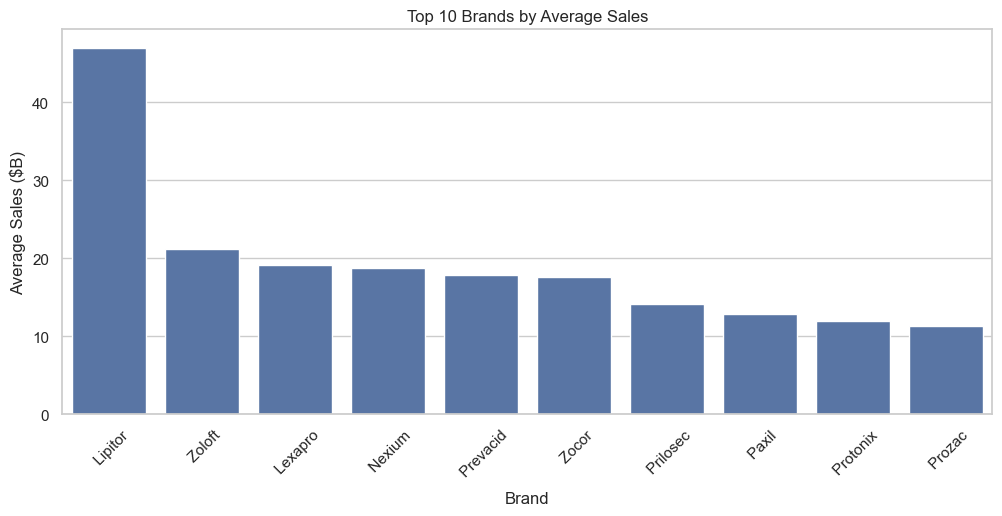


[Business Insight]
The top 5 agents (brands) (Lipitor, Zoloft, Lexapro, Nexium, Prevacid) account for 52.2% of portfolio revenue.
Lipitor alone contributes ~20%. A 10% decline in Lipitor has roughly the same revenue impact
as losing the bottom 8 agents (brands) entirely.
Budget decisions around these high-revenue agents (brands) carry outsized portfolio risk.


In [245]:
print("\n[EDA] Ranking brands by average sales contribution...")

brand_sales = (
    df.groupby("agent", as_index=False)["actual_sales"]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

brand_sales["sales_share_pct"] = 100 * brand_sales["actual_sales"] / brand_sales["actual_sales"].sum()
brand_sales["cumulative_share_pct"] = brand_sales["sales_share_pct"].cumsum()

display(brand_sales.head(10))

plt.figure(figsize=(12, 5))
sns.barplot(data=brand_sales.head(10), x="agent", y="actual_sales")
plt.title("Top 10 Brands by Average Sales")
plt.xlabel("Brand")
plt.ylabel("Average Sales ($B)")
plt.xticks(rotation=45)
plt.show()

top_5_share = brand_sales.head(5)["sales_share_pct"].sum()

print("\n[Business Insight]")
print(f"The top 5 agents (brands) (Lipitor, Zoloft, Lexapro, Nexium, Prevacid) account for {top_5_share:.1f}% of portfolio revenue.")
print("Lipitor alone contributes ~20%. A 10% decline in Lipitor has roughly the same revenue impact")
print("as losing the bottom 8 agents (brands) entirely.")
print("Budget decisions around these high-revenue agents (brands) carry outsized portfolio risk.")

## 2. Growth Trajectory
Before asking which marketing works, we need to understand whether the portfolio is expanding, maturing, or declining.


[EDA] Analyzing portfolio growth trajectory over time...


,year,actual_sales,detailing,direct_to_consumer_ad,sales_yoy_pct,detailing_yoy_pct,dtca_yoy_pct
0,2013,9.9486,45.7758,6.3109,NaN,NaN,NaN
1,2014,11.5475,55.2130,16.1484,16.0714,20.6161,155.8812
2,2015,13.1646,50.1752,16.3910,14.0041,-9.1242,1.5025
3,2016,14.4348,54.1879,15.6212,9.6486,7.9974,-4.6969
4,2017,14.4936,58.6714,31.1021,0.4072,8.2740,99.1020
5,2018,13.9928,57.9632,29.7359,-3.4555,-1.2071,-4.3926
6,2019,12.6725,54.2737,32.8522,-9.4353,-6.3652,10.4801
7,2020,12.1514,65.0097,34.3327,-4.1124,19.7812,4.5066
8,2021,11.4936,67.2739,42.0747,-5.4132,3.4829,22.5497
9,2022,10.6978,59.1707,28.6292,-6.9237,-12.0451,-31.9561


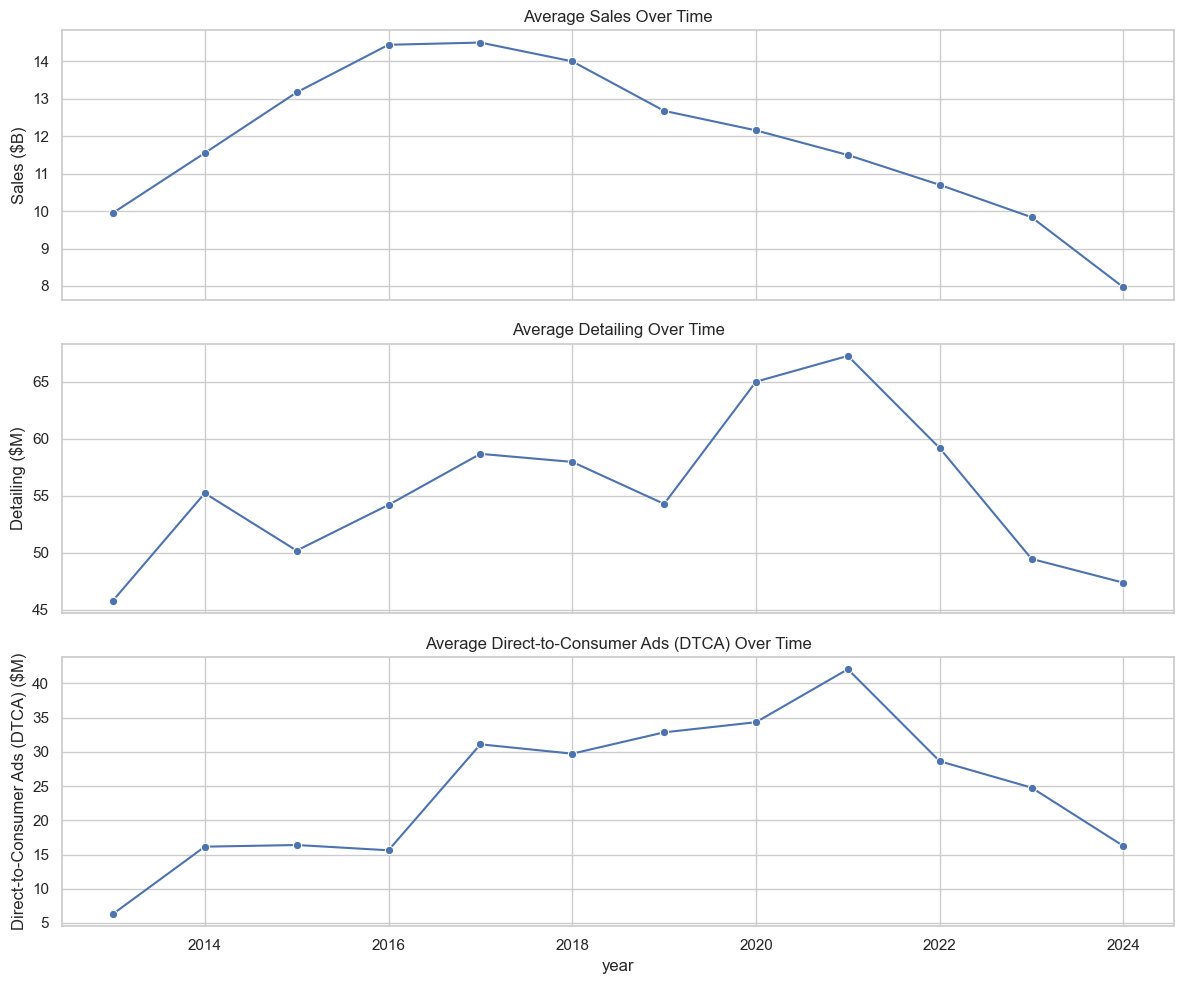


[Business Insight]
Average sales peaked at ~$14.5B (2017) and declined ~45% to ~$8B by 2024.
Detailing peaked in 2020-2021, Direct-to-Consumer Ads (DTCA) peaked in 2021 before a sharp -34% drop in 2024.
Marketing spend during this declining phase may be defending existing revenue rather than driving growth.
This distinction matters for how we interpret any efficiency metrics going forward.


In [246]:
print("\n[EDA] Analyzing portfolio growth trajectory over time...")

yearly = (
    df.groupby("year", as_index=False)[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
)

yearly["sales_yoy_pct"] = yearly["actual_sales"].pct_change() * 100
yearly["detailing_yoy_pct"] = yearly["detailing"].pct_change() * 100
yearly["dtca_yoy_pct"] = yearly["direct_to_consumer_ad"].pct_change() * 100

display(yearly)

# Note: 'yearly' is already aggregated via .mean() above, so these are average values across brands per year.
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

sns.lineplot(data=yearly, x="year", y="actual_sales", marker="o", ax=axes[0])
axes[0].set_title("Average Sales Over Time")
axes[0].set_ylabel("Sales ($B)")

sns.lineplot(data=yearly, x="year", y="detailing", marker="o", ax=axes[1])
axes[1].set_title("Average Detailing Over Time")
axes[1].set_ylabel("Detailing ($M)")

sns.lineplot(data=yearly, x="year", y="direct_to_consumer_ad", marker="o", ax=axes[2])
axes[2].set_title("Average Direct-to-Consumer Ads (DTCA) Over Time")
axes[2].set_ylabel("Direct-to-Consumer Ads (DTCA) ($M)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("Average sales peaked at ~$14.5B (2017) and declined ~45% to ~$8B by 2024.")
print("Detailing peaked in 2020-2021, Direct-to-Consumer Ads (DTCA) peaked in 2021 before a sharp -34% drop in 2024.")
print("Marketing spend during this declining phase may be defending existing revenue rather than driving growth.")
print("This distinction matters for how we interpret any efficiency metrics going forward.")


[EDA] Comparing class-level sales trends over time...


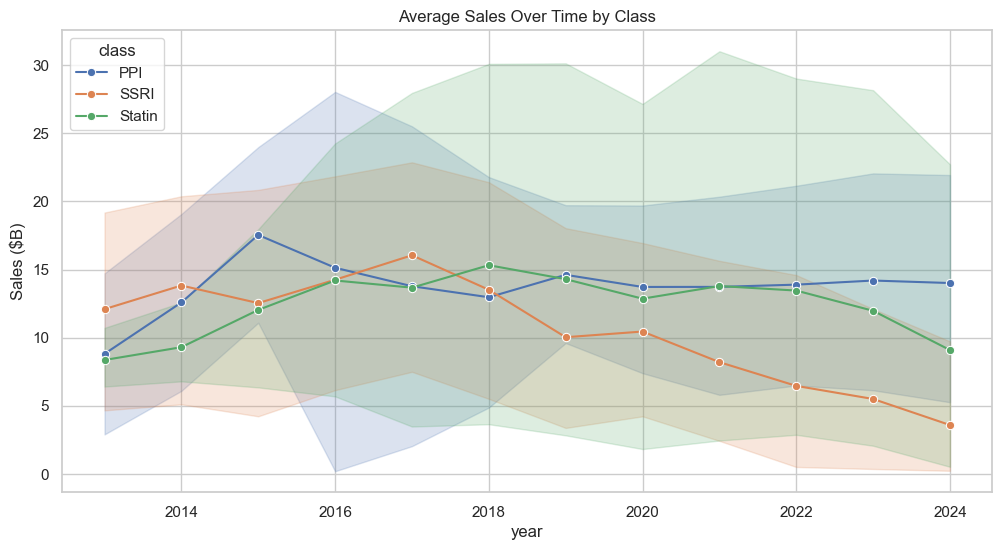


[Business Insight]
PPI (Proton Pump Inhibitors), SSRI (Antidepressants), and Statin (Cholesterol) follow distinct trajectories.
Statins have the widest range driven by Lipitor; SSRIs peaked ~2018 then declined sharply; PPIs are most stable but contracting.
A single portfolio growth narrative is misleading. Strategy reviews should be conducted at the class level.


In [247]:
print("\n[EDA] Comparing class-level sales trends over time...")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="actual_sales", hue="class", marker="o")
plt.title("Average Sales Over Time by Class")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("PPI (Proton Pump Inhibitors), SSRI (Antidepressants), and Statin (Cholesterol) follow distinct trajectories.")
print("Statins have the widest range driven by Lipitor; SSRIs peaked ~2018 then declined sharply; PPIs are most stable but contracting.")
print("A single portfolio growth narrative is misleading. Strategy reviews should be conducted at the class level.")

## 3. Budget Allocation
The next question is how the firm allocates detailing and Direct-to-Consumer Ads (DTCA) budgets across classes and brands.


[EDA] Summarizing average budget allocation by class...


,class,actual_sales,detailing,direct_to_consumer_ad
0,PPI,13.8355,78.5221,42.9419
2,Statin,12.4964,48.5592,31.7618
1,SSRI,9.5923,49.9067,11.2310


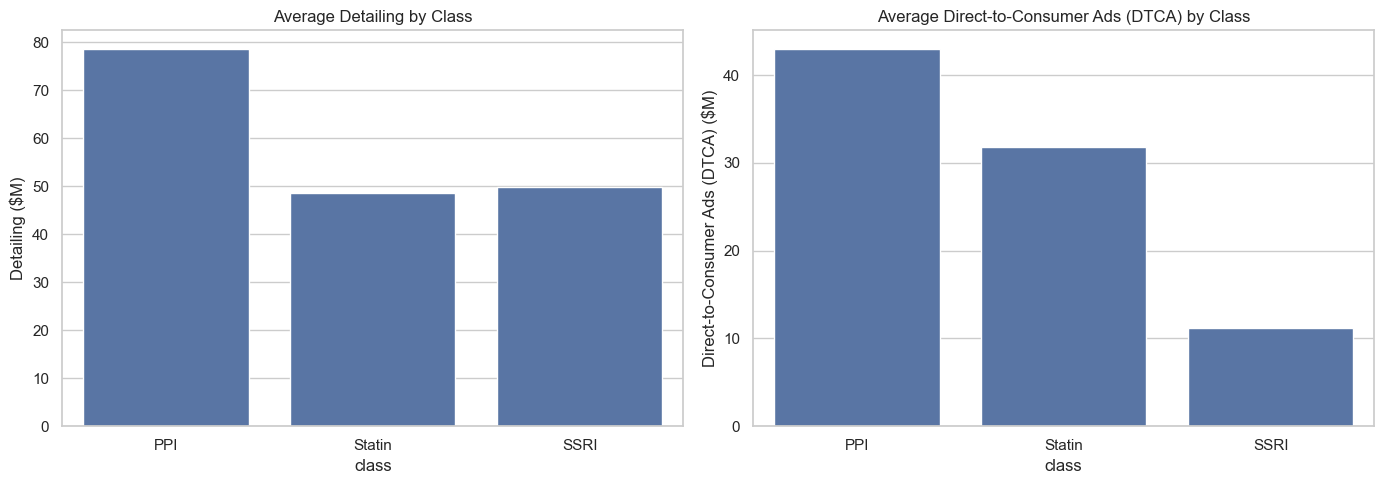


[Business Insight]
PPI (Proton Pump Inhibitors): highest in both channels ($79M detailing, $43M Direct-to-Consumer Ads (DTCA)).
Statin (Cholesterol): moderate both ($49M detailing, $32M Direct-to-Consumer Ads (DTCA)).
SSRI (Antidepressants): comparable detailing ($50M) but minimal Direct-to-Consumer Ads (DTCA) ($11M), heavily physician-driven.
The firm already differentiates channel strategy by class. Any cross-class reallocation represents
a fundamentally different go-to-market approach, not a marginal adjustment.


In [248]:
print("\n[EDA] Summarizing average budget allocation by class...")

class_spend = (
    df.groupby("class", as_index=False)[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

display(class_spend)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=class_spend, x="class", y="detailing", ax=axes[0])
axes[0].set_title("Average Detailing by Class")
axes[0].set_ylabel("Detailing ($M)")

sns.barplot(data=class_spend, x="class", y="direct_to_consumer_ad", ax=axes[1])
axes[1].set_title("Average Direct-to-Consumer Ads (DTCA) by Class")
axes[1].set_ylabel("Direct-to-Consumer Ads (DTCA) ($M)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("PPI (Proton Pump Inhibitors): highest in both channels ($79M detailing, $43M Direct-to-Consumer Ads (DTCA)).")
print("Statin (Cholesterol): moderate both ($49M detailing, $32M Direct-to-Consumer Ads (DTCA)).")
print("SSRI (Antidepressants): comparable detailing ($50M) but minimal Direct-to-Consumer Ads (DTCA) ($11M), heavily physician-driven.")
print("The firm already differentiates channel strategy by class. Any cross-class reallocation represents")
print("a fundamentally different go-to-market approach, not a marginal adjustment.")

In [249]:
print("\n[EDA] Identifying brands with the highest marketing investment...")

brand_spend = (
    df.groupby("agent", as_index=False)[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
    .sort_values("detailing", ascending=False)
)

display(brand_spend.head(10))

print("\n[Business Insight]")
print("Agent (brand) strategies diverge sharply:")
print("  Lexapro (SSRI) = $193M detailing, near-zero Direct-to-Consumer Ads (DTCA) (pure physician push);")
print("  Nexium (PPI) = $153M detailing + $183M Direct-to-Consumer Ads (DTCA) (highest dual-channel investor);")
print("  Crestor (Statin) = $143M detailing + $119M Direct-to-Consumer Ads (DTCA) (heavy investment despite moderate $8B sales).")
print("This variation provides natural experiments for disentangling the separate effects of each channel.")


[EDA] Identifying brands with the highest marketing investment...


,agent,actual_sales,detailing,direct_to_consumer_ad
6,Lexapro,19.1402,192.7008,0.7499
10,Nexium,18.7587,153.0828,182.8566
3,Crestor,7.9550,142.5837,119.2919
7,Lipitor,47.0275,124.0093,80.7884
15,Prevacid,17.8747,92.0651,38.7137
17,Protonix,12.0249,83.2735,3.3244
21,Zoloft,21.1441,80.4162,30.3664
20,Zocor,17.6050,70.3491,54.1879
0,Aciphex,5.8032,66.7499,1.1366
12,Paxil CR,4.8374,53.8639,24.0865



[Business Insight]
Agent (brand) strategies diverge sharply:
  Lexapro (SSRI) = $193M detailing, near-zero Direct-to-Consumer Ads (DTCA) (pure physician push);
  Nexium (PPI) = $153M detailing + $183M Direct-to-Consumer Ads (DTCA) (highest dual-channel investor);
  Crestor (Statin) = $143M detailing + $119M Direct-to-Consumer Ads (DTCA) (heavy investment despite moderate $8B sales).
This variation provides natural experiments for disentangling the separate effects of each channel.


## 4. Baseline Efficiency
Before formal modeling, it is useful to compute simple descriptive efficiency ratios: how much revenue is associated with each unit of spend?

In [250]:
print("\n[EDA] Computing descriptive baseline efficiency by channel...")

efficiency = df.copy()
efficiency["sales_per_detailing"] = np.where(
    efficiency["detailing"] > 0,
    efficiency["actual_sales"] / efficiency["detailing"],
    np.nan
)
efficiency["sales_per_dtca"] = np.where(
    efficiency["direct_to_consumer_ad"] > 0,
    efficiency["actual_sales"] / efficiency["direct_to_consumer_ad"],
    np.nan
)

efficiency_summary = (
    efficiency.groupby("class")[["sales_per_detailing", "sales_per_dtca"]]
    .mean()
    .sort_values("sales_per_detailing", ascending=False)
)

display(efficiency_summary)

avg_eff = efficiency[["sales_per_detailing", "sales_per_dtca"]].mean()
display(avg_eff.to_frame("portfolio_avg_efficiency"))

print("\n[Business Insight]")
print("Detailing shows a more consistent sales-per-dollar relationship across all three classes")
print("(Statin: $0.55B/$M, PPI: $0.39B/$M, SSRI: $0.36B/$M).")
print("Direct-to-Consumer Ads (DTCA) ratios are unreliable. SSRI's apparent $1,979B/$M is an artifact of near-zero spend denominators.")
print("Directionally, detailing appears to be the more stable revenue driver. Do not use these ratios for")
print("budget reallocation; the parametric and ML models will isolate true incremental effects.")


[EDA] Computing descriptive baseline efficiency by channel...


,sales_per_detailing,sales_per_dtca
class,,
Statin,0.5474,59.6006
PPI,0.3913,335.6168
SSRI,0.3591,"1,979.3762"


,portfolio_avg_efficiency
sales_per_detailing,0.4387
sales_per_dtca,739.4620



[Business Insight]
Detailing shows a more consistent sales-per-dollar relationship across all three classes
(Statin: $0.55B/$M, PPI: $0.39B/$M, SSRI: $0.36B/$M).
Direct-to-Consumer Ads (DTCA) ratios are unreliable. SSRI's apparent $1,979B/$M is an artifact of near-zero spend denominators.
Directionally, detailing appears to be the more stable revenue driver. Do not use these ratios for
budget reallocation; the parametric and ML models will isolate true incremental effects.


## 5. Distribution Shape and Market Structure
We now examine whether sales and spend are broadly distributed or concentrated in a small number of observations.


[EDA] Visualizing raw distributions of sales and marketing spend...


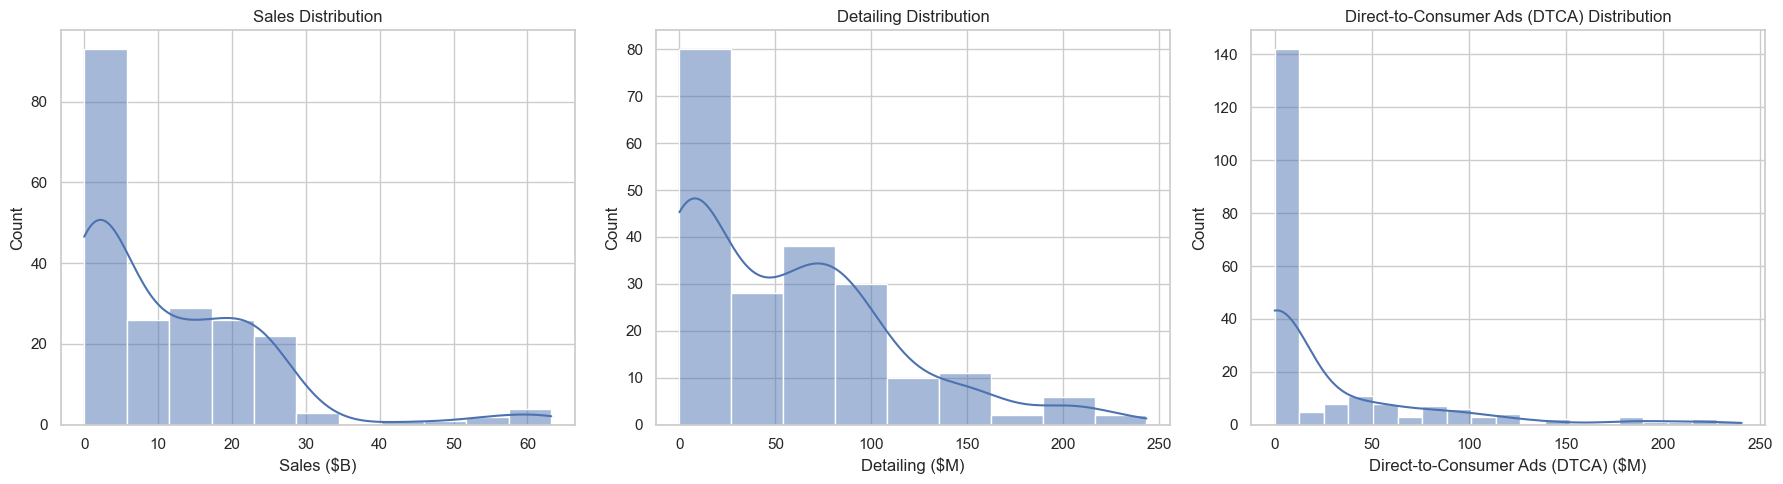


[Business Insight]
Sales, detailing, and Direct-to-Consumer Ads (DTCA) are all heavily skewed to the right.
Most agents (brands) have low-to-moderate values, but a few (like Lipitor and Nexium) have very high values.
This concentration means raw averages and simple regressions will be pulled toward these large agents (brands).


In [251]:
print("\n[EDA] Visualizing raw distributions of sales and marketing spend...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0])
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales ($B)")

sns.histplot(df["detailing"], kde=True, ax=axes[1])
axes[1].set_title("Detailing Distribution")
axes[1].set_xlabel("Detailing ($M)")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2])
axes[2].set_title("Direct-to-Consumer Ads (DTCA) Distribution")
axes[2].set_xlabel("Direct-to-Consumer Ads (DTCA) ($M)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("Sales, detailing, and Direct-to-Consumer Ads (DTCA) are all heavily skewed to the right.")
print("Most agents (brands) have low-to-moderate values, but a few (like Lipitor and Nexium) have very high values.")
print("This concentration means raw averages and simple regressions will be pulled toward these large agents (brands).")

In [252]:
print("\n[EDA] Quantifying skewness in raw variables...")

skewness_raw = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew()
display(skewness_raw.to_frame("skewness"))

print("\n[Business Insight]")
print("Skewness values above 1.0 confirm the distributions are significantly lopsided.")
print("Using raw values directly in regression would let a few extreme data points dominate the results.")
print("This is why we will apply log transformations before modeling.")


[EDA] Quantifying skewness in raw variables...


,skewness
actual_sales,1.7127
detailing,1.0358
direct_to_consumer_ad,2.2988



[Business Insight]
Skewness values above 1.0 confirm the distributions are significantly lopsided.
Using raw values directly in regression would let a few extreme data points dominate the results.
This is why we will apply log transformations before modeling.


## 6. Spend Saturation and Diminishing Returns
The next business question is whether more spend always produces proportionally more sales.


[EDA] Testing for diminishing returns in detailing using LOWESS...


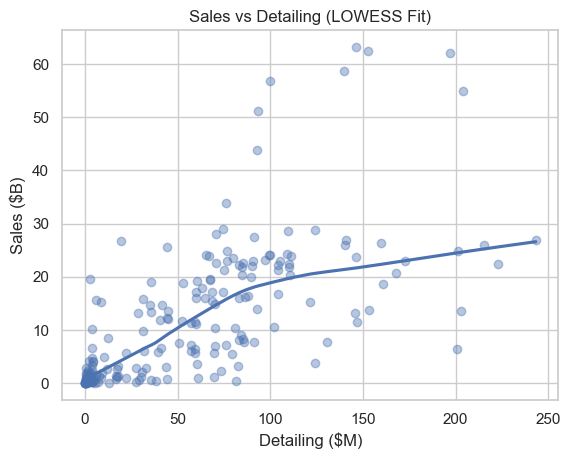


[Business Insight]
The LOWESS curve shows clear diminishing returns: the first $50M of detailing generates substantially
more sales lift than the next $50M, and the curve flattens beyond $100M.
For agents (brands) already spending $100M+ (Lexapro, Nexium, Lipitor, Crestor), incremental detailing
dollars yield progressively less return. Reallocation to under-invested agents (brands) could improve portfolio ROI.


In [253]:
print("\n[EDA] Testing for diminishing returns in detailing using LOWESS...")

sns.regplot(
    data=df,
    x="detailing",
    y="actual_sales",
    lowess=True,
    scatter_kws={"alpha": 0.4}
)

plt.title("Sales vs Detailing (LOWESS Fit)")
plt.xlabel("Detailing ($M)")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("The LOWESS curve shows clear diminishing returns: the first $50M of detailing generates substantially")
print("more sales lift than the next $50M, and the curve flattens beyond $100M.")
print("For agents (brands) already spending $100M+ (Lexapro, Nexium, Lipitor, Crestor), incremental detailing")
print("dollars yield progressively less return. Reallocation to under-invested agents (brands) could improve portfolio ROI.")

In [254]:
print("\n[EDA] Approximating where detailing saturation begins...")

df["detailing_bucket"] = pd.qcut(df["detailing"], q=10, duplicates="drop")
bucket_sales = df.groupby("detailing_bucket", observed=False)["actual_sales"].mean().to_frame("avg_sales")

display(bucket_sales)

print("\n[Business Insight - Detailing Saturation Threshold]")
print("Bucketed analysis identifies where returns diminish:")
print("  $0-29M: moderate marginal returns (~$1-1.6B added per bucket).")
print("  $29-80M: peak efficiency zone (~$4B per bucket).")
print("  $80-93M: plateau, sales actually dip slightly (saturation onset).")
print("Agents (brands) spending above ~$80M should evaluate whether marginal dollars deliver better returns elsewhere.")


[EDA] Approximating where detailing saturation begins...


,avg_sales
detailing_bucket,
"(-0.001, 0.639]",0.3719
"(0.639, 2.96]",2.0414
"(2.96, 6.907]",2.9686
"(6.907, 28.631]",4.5371
"(28.631, 44.969]",8.5018
"(44.969, 67.258]",12.4589
"(67.258, 80.046]",16.5847
"(80.046, 92.864]",16.3139
"(92.864, 134.211]",23.0129



[Business Insight - Detailing Saturation Threshold]
Bucketed analysis identifies where returns diminish:
  $0-29M: moderate marginal returns (~$1-1.6B added per bucket).
  $29-80M: peak efficiency zone (~$4B per bucket).
  $80-93M: plateau, sales actually dip slightly (saturation onset).
Agents (brands) spending above ~$80M should evaluate whether marginal dollars deliver better returns elsewhere.



[EDA] Testing for diminishing returns in Direct-to-Consumer Ads (DTCA) among active advertisers...


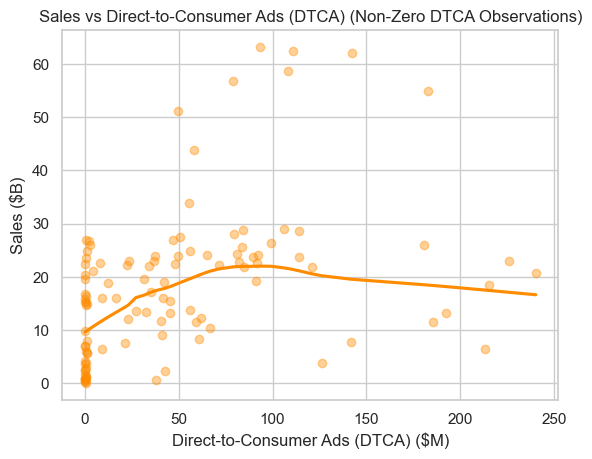


[Business Insight]
Among agents (brands) that invest in Direct-to-Consumer Ads (DTCA), higher spend is associated with higher sales,
but the relationship is less consistent than detailing. Similar spend levels produce varying outcomes.
Agent (brand)-specific factors (market position, class, complementary detailing) likely moderate
Direct-to-Consumer Ads (DTCA) effectiveness. The modeling phase will quantify whether the incremental impact
is significant after controlling for these factors.


In [255]:
print("\n[EDA] Testing for diminishing returns in Direct-to-Consumer Ads (DTCA) among active advertisers...")

non_zero_dtca = df[df["direct_to_consumer_ad"] > 0]

sns.regplot(
    data=non_zero_dtca,
    x="direct_to_consumer_ad",
    y="actual_sales",
    lowess=True,
    scatter_kws={"alpha": 0.4},
    color="darkorange"
)

plt.title("Sales vs Direct-to-Consumer Ads (DTCA) (Non-Zero DTCA Observations)")
plt.xlabel("Direct-to-Consumer Ads (DTCA) ($M)")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("Among agents (brands) that invest in Direct-to-Consumer Ads (DTCA), higher spend is associated with higher sales,")
print("but the relationship is less consistent than detailing. Similar spend levels produce varying outcomes.")
print("Agent (brand)-specific factors (market position, class, complementary detailing) likely moderate")
print("Direct-to-Consumer Ads (DTCA) effectiveness. The modeling phase will quantify whether the incremental impact")
print("is significant after controlling for these factors.")

## 7. Class and Brand Differences in Baseline Sales and Response
A key strategic issue is whether classes and brands differ structurally in both scale and likely marketing response.


[EDA] Comparing baseline sales by class...


,class,actual_sales
0,PPI,13.8355
2,Statin,12.4964
1,SSRI,9.5923


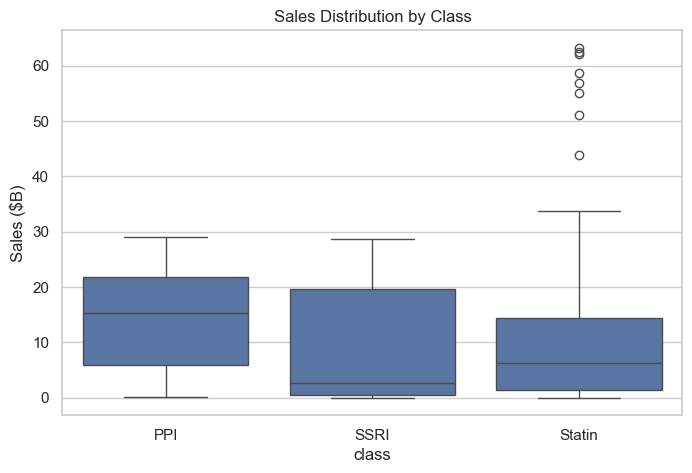


[Business Insight]
PPI (Proton Pump Inhibitors) agents (brands) average $13.8B, Statin (Cholesterol) $12.5B, SSRI (Antidepressants) $9.6B.
Within-class variation is substantial: Statin agents (brands) range from ~$2B (Mevacor) to ~$47B (Lipitor).
Marketing budgets calibrated to class averages will over-invest in small agents (brands) and under-invest in large ones.


In [256]:
print("\n[EDA] Comparing baseline sales by class...")

avg_sales_by_class = (
    df.groupby("class", as_index=False)["actual_sales"]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

display(avg_sales_by_class)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="class", y="actual_sales")
plt.title("Sales Distribution by Class")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("PPI (Proton Pump Inhibitors) agents (brands) average $13.8B, Statin (Cholesterol) $12.5B, SSRI (Antidepressants) $9.6B.")
print("Within-class variation is substantial: Statin agents (brands) range from ~$2B (Mevacor) to ~$47B (Lipitor).")
print("Marketing budgets calibrated to class averages will over-invest in small agents (brands) and under-invest in large ones.")


[EDA] Comparing baseline sales by brand...


,agent,actual_sales
7,Lipitor,47.0275
21,Zoloft,21.1441
6,Lexapro,19.1402
10,Nexium,18.7587
15,Prevacid,17.8747
20,Zocor,17.6050
16,Prilosec,14.1557
11,Paxil,12.8184
17,Protonix,12.0249
18,Prozac,11.2791


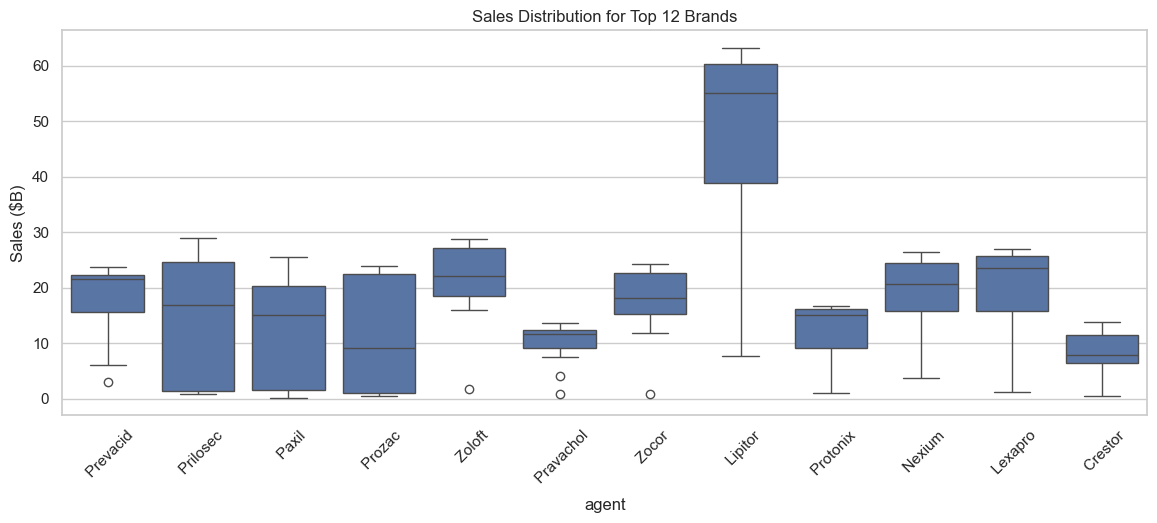


[Business Insight]
Lipitor ($47B avg) generates ~50x the revenue of Luvox ($0.6B). Even within Statin (Cholesterol),
agent (brand) scale varies 10-30x. A large agent (brand) may show high 'efficiency' simply because of its size,
not better marketing. The modeling phase will include agent (brand)-level controls to isolate true marketing response.


In [257]:
print("\n[EDA] Comparing baseline sales by brand...")

avg_sales_by_agent = (
    df.groupby("agent", as_index=False)["actual_sales"]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

display(avg_sales_by_agent.head(15))

top_agents = avg_sales_by_agent.head(12)["agent"].tolist()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df[df["agent"].isin(top_agents)], x="agent", y="actual_sales")
plt.title("Sales Distribution for Top 12 Brands")
plt.ylabel("Sales ($B)")
plt.xticks(rotation=45)
plt.show()

print("\n[Business Insight]")
print("Lipitor ($47B avg) generates ~50x the revenue of Luvox ($0.6B). Even within Statin (Cholesterol),")
print("agent (brand) scale varies 10-30x. A large agent (brand) may show high 'efficiency' simply because of its size,")
print("not better marketing. The modeling phase will include agent (brand)-level controls to isolate true marketing response.")

## 8. Structural Zero-Direct-to-Consumer Ads (DTCA) Regime
A large share of observations show exactly zero Direct-to-Consumer Ads (DTCA), which may reflect a distinct strategic regime rather than just low spend.

In [258]:
print("\n[EDA] Measuring the prevalence and structure of zero Direct-to-Consumer Ads (DTCA)...")

df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

zero_dtca = df["dtca_zero"].sum()
total = len(df)

print(f"Zero Direct-to-Consumer Ads (DTCA) observations: {zero_dtca}")
print(f"Total observations: {total}")
print(f"Share of zero-Direct-to-Consumer Ads (DTCA) observations: {zero_dtca / total:.2%}")

print("\nZero Direct-to-Consumer Ads (DTCA) by class:")
display(pd.crosstab(df["class"], df["dtca_zero"]))

print("\nZero Direct-to-Consumer Ads (DTCA) by year:")
display(pd.crosstab(df["year"], df["dtca_zero"]))

print("\n[Business Insight]")
print("47% of agent (brand)-year observations have zero Direct-to-Consumer Ads (DTCA), reflecting a deliberate strategic choice, not under-investment.")
print("SSRI (Antidepressants) agents (brands) are most physician-driven (58% zero Direct-to-Consumer Ads (DTCA)).")
print("The portfolio operates under two models:")
print("  (1) Detailing-only / physician push, (2) Dual-channel / detailing + Direct-to-Consumer Ads (DTCA).")
print("Pooling both groups when evaluating Direct-to-Consumer Ads (DTCA) would be misleading. The modeling phase will include a regime indicator.")


[EDA] Measuring the prevalence and structure of zero Direct-to-Consumer Ads (DTCA)...
Zero Direct-to-Consumer Ads (DTCA) observations: 98
Total observations: 207
Share of zero-Direct-to-Consumer Ads (DTCA) observations: 47.34%

Zero Direct-to-Consumer Ads (DTCA) by class:


dtca_zero,0,1
class,,
PPI,32,16
SSRI,34,47
Statin,43,35



Zero Direct-to-Consumer Ads (DTCA) by year:


dtca_zero,0,1
year,,
2013,3,7
2014,5,6
2015,6,6
2016,6,7
2017,7,8
2018,12,5
2019,12,8
2020,10,11
2021,13,9



[Business Insight]
47% of agent (brand)-year observations have zero Direct-to-Consumer Ads (DTCA), reflecting a deliberate strategic choice, not under-investment.
SSRI (Antidepressants) agents (brands) are most physician-driven (58% zero Direct-to-Consumer Ads (DTCA)).
The portfolio operates under two models:
  (1) Detailing-only / physician push, (2) Dual-channel / detailing + Direct-to-Consumer Ads (DTCA).
Pooling both groups when evaluating Direct-to-Consumer Ads (DTCA) would be misleading. The modeling phase will include a regime indicator.


## 9. Log Transformations for Parametric Modeling
Because the raw variables are highly skewed and the commercial response appears multiplicative, we prepare log variables for the next stage.

In [259]:
print("\n[EDA] Creating log-transformed variables for next-stage modeling...")

df["log_sales"] = np.log1p(df["actual_sales"])
df["log_detailing"] = np.log1p(df["detailing"])
df["log_dtca"] = np.log1p(df["direct_to_consumer_ad"])

print("[EDA] Log variables created: log_sales, log_detailing, log_dtca")


[EDA] Creating log-transformed variables for next-stage modeling...
[EDA] Log variables created: log_sales, log_detailing, log_dtca



[EDA] Comparing raw and log-transformed distributions...


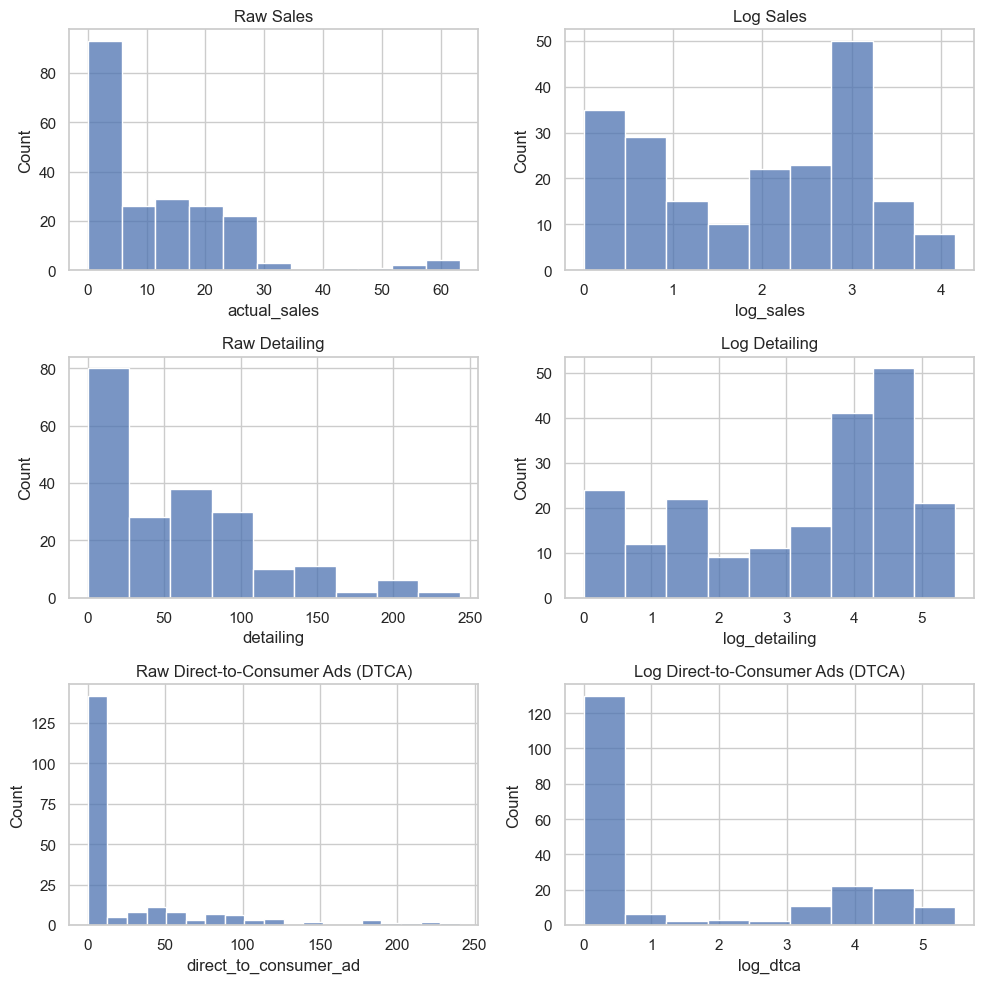


[Business Insight]
After log transformation, sales and detailing distributions become much more symmetric and spread out evenly.
Direct-to-Consumer Ads (DTCA) also improves, but the large spike at zero remains because log(1+0) = 0 for all zero-Direct-to-Consumer Ads (DTCA) observations.
This spike is not a problem. It is a real feature of the data that the model will handle via the zero-Direct-to-Consumer Ads (DTCA) indicator.


In [260]:
print("\n[EDA] Comparing raw and log-transformed distributions...")

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

sns.histplot(df["actual_sales"], ax=axes[0, 0])
axes[0, 0].set_title("Raw Sales")

sns.histplot(df["log_sales"], ax=axes[0, 1])
axes[0, 1].set_title("Log Sales")

sns.histplot(df["detailing"], ax=axes[1, 0])
axes[1, 0].set_title("Raw Detailing")

sns.histplot(df["log_detailing"], ax=axes[1, 1])
axes[1, 1].set_title("Log Detailing")

sns.histplot(df["direct_to_consumer_ad"], ax=axes[2, 0])
axes[2, 0].set_title("Raw Direct-to-Consumer Ads (DTCA)")

sns.histplot(df["log_dtca"], ax=axes[2, 1])
axes[2, 1].set_title("Log Direct-to-Consumer Ads (DTCA)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("After log transformation, sales and detailing distributions become much more symmetric and spread out evenly.")
print("Direct-to-Consumer Ads (DTCA) also improves, but the large spike at zero remains because log(1+0) = 0 for all zero-Direct-to-Consumer Ads (DTCA) observations.")
print("This spike is not a problem. It is a real feature of the data that the model will handle via the zero-Direct-to-Consumer Ads (DTCA) indicator.")


[EDA] Evaluating log-log relationships...


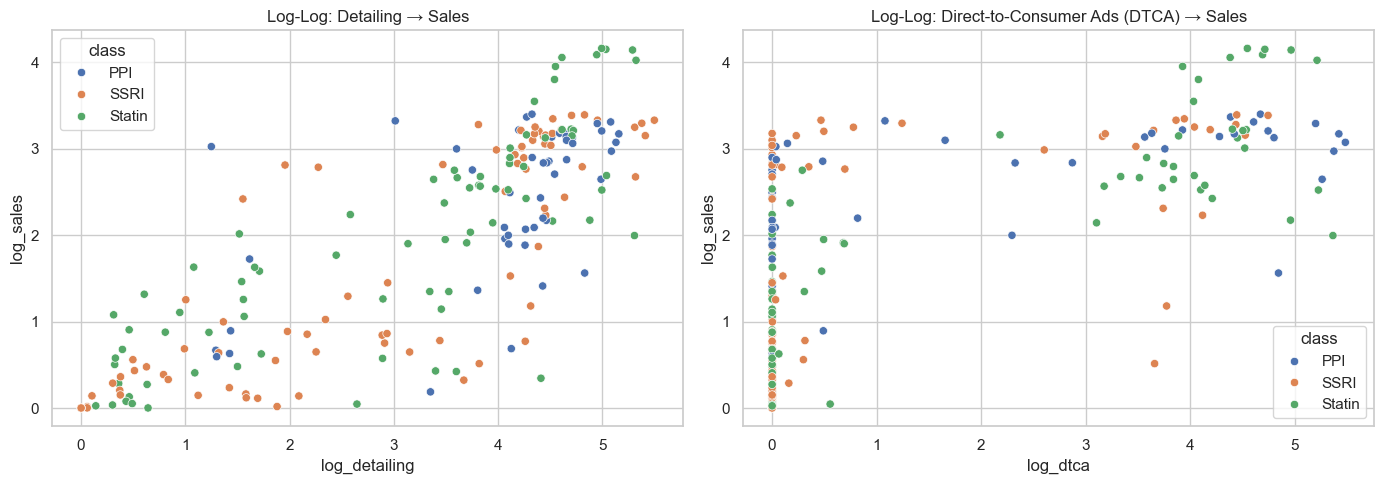


[Business Insight]
In log space, the relationship between marketing spend and sales becomes much closer to a straight line.
This means a log-log regression is appropriate, where coefficients represent elasticities:
e.g., a coefficient of 0.3 means a 1% increase in detailing is associated with a 0.3% increase in sales.


In [261]:
print("\n[EDA] Evaluating log-log relationships...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="log_detailing", y="log_sales", hue="class", ax=axes[0])
axes[0].set_title("Log-Log: Detailing → Sales")

sns.scatterplot(data=df, x="log_dtca", y="log_sales", hue="class", ax=axes[1])
axes[1].set_title("Log-Log: Direct-to-Consumer Ads (DTCA) → Sales")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("In log space, the relationship between marketing spend and sales becomes much closer to a straight line.")
print("This means a log-log regression is appropriate, where coefficients represent elasticities:")
print("e.g., a coefficient of 0.3 means a 1% increase in detailing is associated with a 0.3% increase in sales.")


[EDA] Comparing class-level marketing sensitivity in log space...


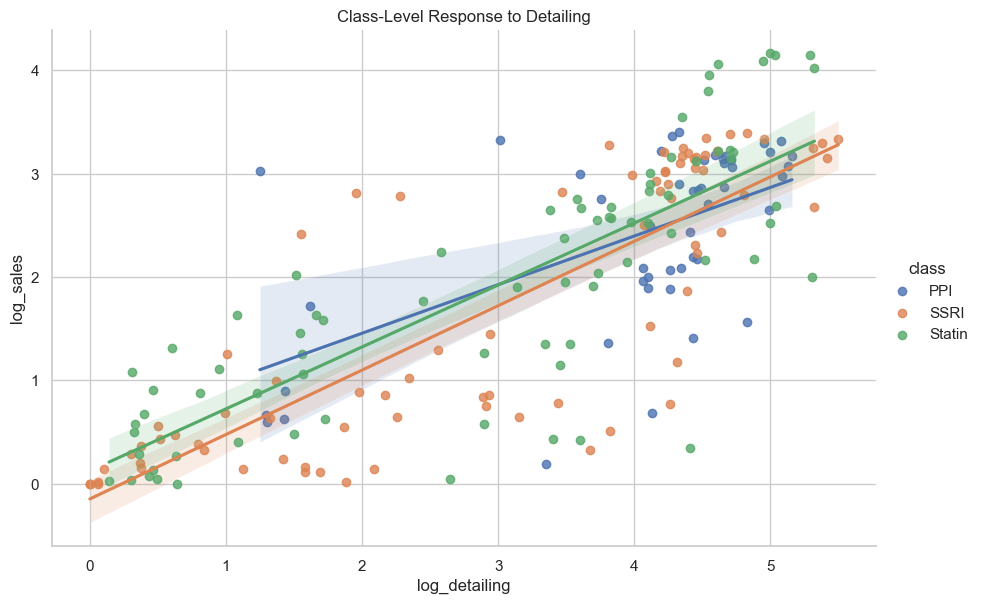


[Business Insight]
Statin (Cholesterol) agents (brands) show the steepest detailing response; SSRI (Antidepressants) the flattest.
A dollar of detailing generates different returns by class. A uniform budget efficiency target is inappropriate.
The modeling phase will quantify class-specific elasticities to support differentiated allocation strategies.


In [262]:
print("\n[EDA] Comparing class-level marketing sensitivity in log space...")

sns.lmplot(
    data=df,
    x="log_detailing",
    y="log_sales",
    hue="class",
    height=6,
    aspect=1.5
)

plt.title("Class-Level Response to Detailing")
plt.show()

print("\n[Business Insight]")
print("Statin (Cholesterol) agents (brands) show the steepest detailing response; SSRI (Antidepressants) the flattest.")
print("A dollar of detailing generates different returns by class. A uniform budget efficiency target is inappropriate.")
print("The modeling phase will quantify class-specific elasticities to support differentiated allocation strategies.")

## 10. Cross-Channel Strategy and Collinearity
Do brands tend to invest in both channels together, or do they specialize?


[EDA] Examining the relationship between detailing and Direct-to-Consumer Ads (DTCA)...


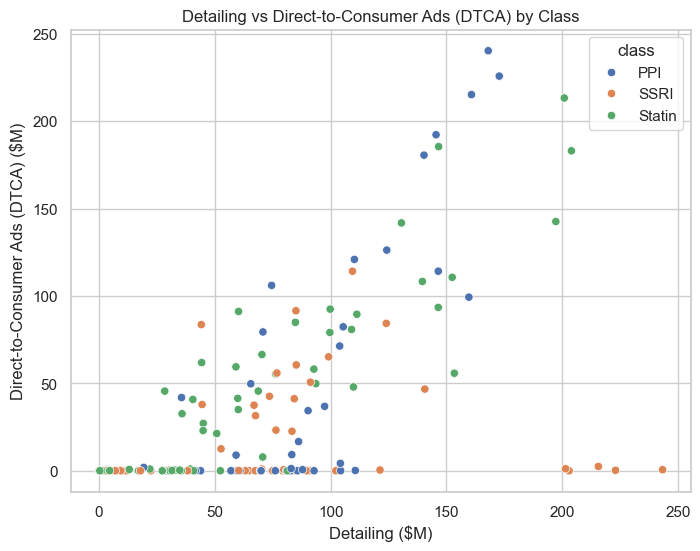


[Business Insight]
PPI (Proton Pump Inhibitors) and Statin (Cholesterol) agents (brands) tend to invest in both channels together.
SSRI (Antidepressants) agents (brands) cluster at high detailing / low Direct-to-Consumer Ads (DTCA).
Because channels move together for PPI/Statin, isolating each channel's independent effect is harder for those classes.


In [263]:
print("\n[EDA] Examining the relationship between detailing and Direct-to-Consumer Ads (DTCA)...")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="detailing",
    y="direct_to_consumer_ad",
    hue="class"
)
plt.title("Detailing vs Direct-to-Consumer Ads (DTCA) by Class")
plt.xlabel("Detailing ($M)")
plt.ylabel("Direct-to-Consumer Ads (DTCA) ($M)")
plt.show()

print("\n[Business Insight]")
print("PPI (Proton Pump Inhibitors) and Statin (Cholesterol) agents (brands) tend to invest in both channels together.")
print("SSRI (Antidepressants) agents (brands) cluster at high detailing / low Direct-to-Consumer Ads (DTCA).")
print("Because channels move together for PPI/Statin, isolating each channel's independent effect is harder for those classes.")


[EDA] Calculating correlation matrix for log-transformed variables...


,log_sales,log_detailing,log_dtca
log_sales,1.0000,0.8027,0.6482
log_detailing,0.8027,1.0000,0.5953
log_dtca,0.6482,0.5953,1.0000


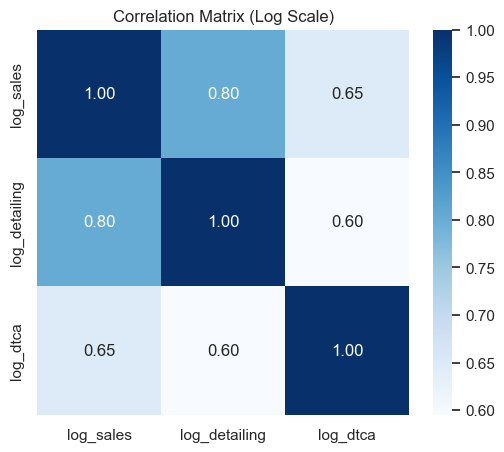


[Business Insight]
Log-detailing and log Direct-to-Consumer Ads (DTCA) correlate at 0.60 (moderate).
Both correlate positively with sales (detailing: 0.80, Direct-to-Consumer Ads (DTCA): 0.65).
Manageable for modeling, but caution is warranted when attributing sales gains to one channel
when both increased simultaneously for the same agent (brand).


In [264]:
print("\n[EDA] Calculating correlation matrix for log-transformed variables...")

corr = df[["log_sales", "log_detailing", "log_dtca"]].corr()

display(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Log Scale)")
plt.show()

print("\n[Business Insight]")
print("Log-detailing and log Direct-to-Consumer Ads (DTCA) correlate at 0.60 (moderate).")
print("Both correlate positively with sales (detailing: 0.80, Direct-to-Consumer Ads (DTCA): 0.65).")
print("Manageable for modeling, but caution is warranted when attributing sales gains to one channel")
print("when both increased simultaneously for the same agent (brand).")

## 11. Panel Structure and Within-Brand Dynamics
To isolate marketing response credibly, we need to look beyond cross-sectional size and examine within-brand changes over time.


[EDA] Exploring within-brand trajectories for selected brands...


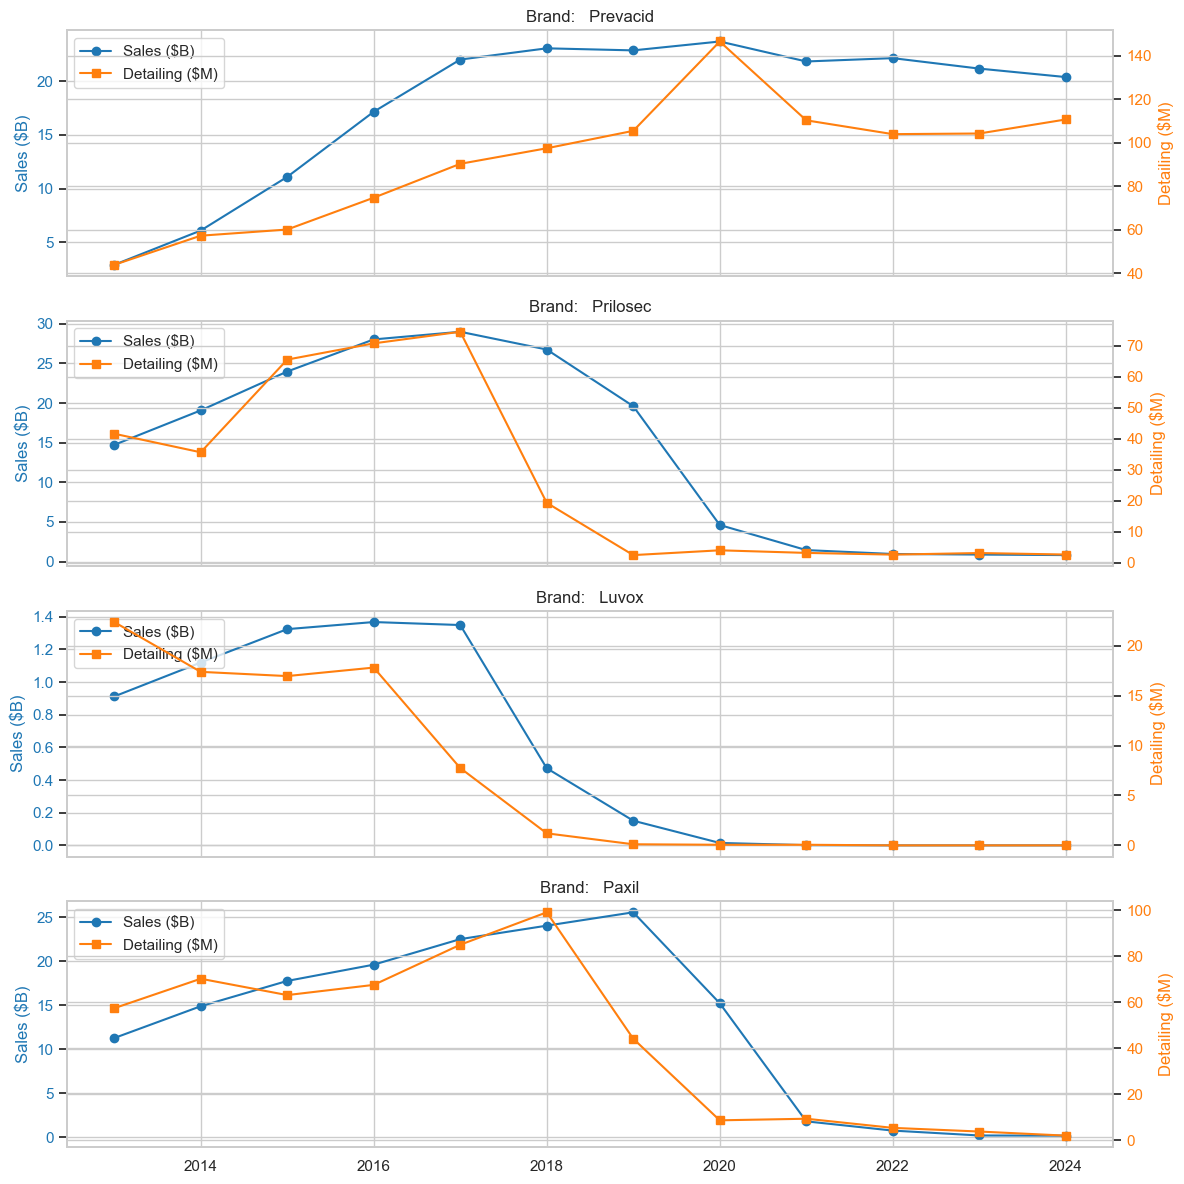


[Business Insight]
Individual trajectories confirm that changes in detailing over time correspond with sales changes:
Prevacid ramped detailing 2013-2017, sales followed; Paxil spiked 2018-2019, then both declined;
Luvox dropped detailing to near zero after 2018, sales declined in parallel.
This within-agent (brand) evidence suggests marketing spend has a real association with sales
beyond the effect of agent (brand) scale alone.


In [265]:
print("\n[EDA] Exploring within-brand trajectories for selected brands...")

sample_agents = df["agent"].drop_duplicates().head(4).tolist()

fig, axes = plt.subplots(len(sample_agents), 1, figsize=(12, 12), sharex=True)

for i, a in enumerate(sample_agents):
    temp = df[df["agent"] == a].sort_values("year")

    color_sales = "#1f77b4"
    axes[i].plot(temp["year"], temp["actual_sales"], marker="o", color=color_sales, label="Sales ($B)")
    axes[i].set_ylabel("Sales ($B)", color=color_sales)
    axes[i].tick_params(axis="y", labelcolor=color_sales)

    ax_right = axes[i].twinx()
    color_detail = "#ff7f0e"
    ax_right.plot(temp["year"], temp["detailing"], marker="s", color=color_detail, label="Detailing ($M)")
    ax_right.set_ylabel("Detailing ($M)", color=color_detail)
    ax_right.tick_params(axis="y", labelcolor=color_detail)

    axes[i].set_title(f"Brand: {a}")
    lines_1, labels_1 = axes[i].get_legend_handles_labels()
    lines_2, labels_2 = ax_right.get_legend_handles_labels()
    axes[i].legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("Individual trajectories confirm that changes in detailing over time correspond with sales changes:")
print("Prevacid ramped detailing 2013-2017, sales followed; Paxil spiked 2018-2019, then both declined;")
print("Luvox dropped detailing to near zero after 2018, sales declined in parallel.")
print("This within-agent (brand) evidence suggests marketing spend has a real association with sales")
print("beyond the effect of agent (brand) scale alone.")


[EDA] Inferring brand lifecycle patterns...


,start_year,end_year,avg_sales
agent,,,
Zoloft,2013,2024,21.1441
Prozac,2013,2024,11.2791
Prilosec,2013,2024,14.1557
Lescol,2013,2024,3.6356
Prevacid,2013,2024,17.8747
Pravachol,2013,2024,9.9861
Luvox,2013,2024,0.5595
Mevacor,2013,2024,2.1499
Zocor,2013,2024,17.6050


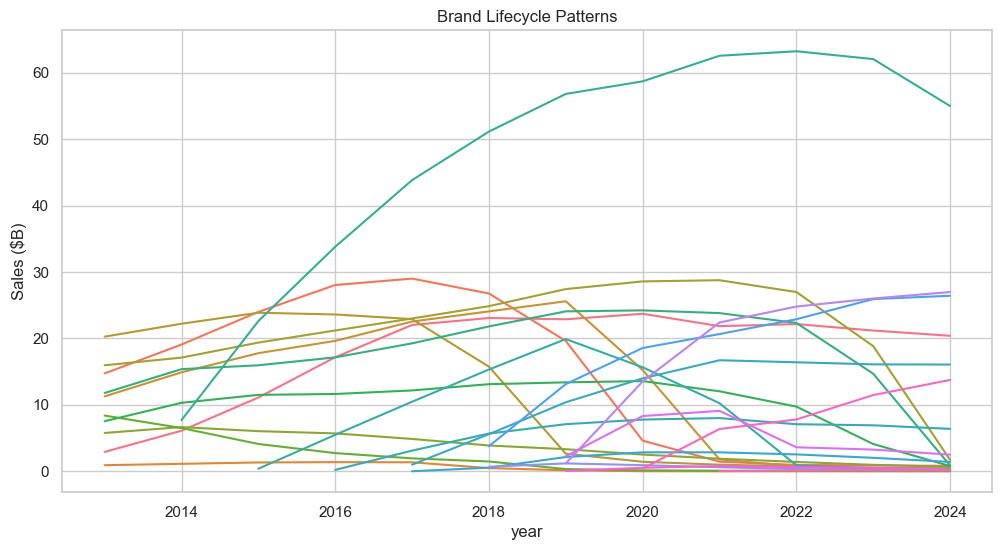


[Business Insight]
Agents (brands) are at different lifecycle stages: Lipitor plateaued, Luvox is in steady decline,
newer entrants like Crestor are still ramping. A growing agent (brand) may appear to have high marketing ROI
simply because of organic growth, and a declining one may appear inefficient despite sound strategy.
The modeling phase will include year and agent (brand) controls to separate lifecycle trends from true marketing impact.


In [266]:
print("\n[EDA] Inferring brand lifecycle patterns...")

agent_lifecycle = (
    df.groupby("agent")
    .agg(
        start_year=("year", "min"),
        end_year=("year", "max"),
        avg_sales=("actual_sales", "mean")
    )
    .sort_values("start_year")
)

display(agent_lifecycle.head(15))

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="actual_sales", hue="agent", legend=False)
plt.title("Brand Lifecycle Patterns")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("Agents (brands) are at different lifecycle stages: Lipitor plateaued, Luvox is in steady decline,")
print("newer entrants like Crestor are still ramping. A growing agent (brand) may appear to have high marketing ROI")
print("simply because of organic growth, and a declining one may appear inefficient despite sound strategy.")
print("The modeling phase will include year and agent (brand) controls to separate lifecycle trends from true marketing impact.")

## 12. Outliers and High-Leverage Observations
Before modeling, we identify whether a few brands or campaigns are likely to dominate results.

In [267]:
print("\n[EDA] Reviewing highest-leverage observations...")

print("Top 5 by sales:")
display(df.nlargest(5, "actual_sales")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("Top 5 by detailing:")
display(df.nlargest(5, "detailing")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("Top 5 by Direct-to-Consumer Ads (DTCA):")
display(df.nlargest(5, "direct_to_consumer_ad")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("\n[Business Insight]")
print("Three agents (brands) dominate the extremes: Lipitor (top sales $55-63B),")
print("Lexapro (top detailing $203-243M), Nexium (top Direct-to-Consumer Ads (DTCA) $192-240M).")
print("These are not anomalies; they reflect real market positions.")
print("Any portfolio-level finding that changes when one of these agents (brands) is removed is really")
print("a finding about that agent (brand), not the portfolio. Robustness checks will flag this distinction.")


[EDA] Reviewing highest-leverage observations...
Top 5 by sales:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
159,Statin,Lipitor,2022,63.2186,146.4874,93.4800
137,Statin,Lipitor,2021,62.5406,152.5107,110.7082
181,Statin,Lipitor,2023,62.0389,197.2503,142.6181
115,Statin,Lipitor,2020,58.6918,139.6403,108.3209
94,Statin,Lipitor,2019,56.7952,99.7099,79.1343


Top 5 by detailing:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
191,SSRI,Lexapro,2024,26.9766,243.3303,0.5963
125,SSRI,Lexapro,2021,22.3924,223.0231,0.2595
169,SSRI,Lexapro,2023,26.0019,215.6069,2.4667
203,Statin,Lipitor,2024,54.9727,203.9765,183.0804
104,SSRI,Lexapro,2020,13.5176,202.9746,0.0000


Top 5 by Direct-to-Consumer Ads (DTCA):


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
120,PPI,Nexium,2021,20.6499,168.0683,240.3550
142,PPI,Nexium,2022,22.8833,172.8186,225.8439
99,PPI,Nexium,2020,18.5523,160.8279,215.2616
134,Statin,Crestor,2021,6.3594,200.9031,213.3158
79,PPI,Nexium,2019,13.1240,145.5416,192.2922



[Business Insight]
Three agents (brands) dominate the extremes: Lipitor (top sales $55-63B),
Lexapro (top detailing $203-243M), Nexium (top Direct-to-Consumer Ads (DTCA) $192-240M).
These are not anomalies; they reflect real market positions.
Any portfolio-level finding that changes when one of these agents (brands) is removed is really
a finding about that agent (brand), not the portfolio. Robustness checks will flag this distinction.


## 13. EDA Takeaways

In [268]:
print("\n" + "="*90)
print("EDA EXECUTIVE SUMMARY")
print("="*90)
print("""
Q1 - REVENUE CONCENTRATION:
  Top 5 agents (brands) account for ~52% of revenue. Lipitor alone = ~20%.
  Budget decisions around these high-revenue agents (brands) carry outsized portfolio risk.

Q2 - GROWTH TRAJECTORY:
  Portfolio sales peaked ~2017 ($14.5B avg), declined ~45% to ~$8B by 2024.
  PPI (Proton Pump Inhibitors), SSRI (Antidepressants), Statin (Cholesterol) are all contracting
  at different rates. Marketing ROI must be evaluated against a shrinking baseline.

Q3 - BUDGET ALLOCATION:
  Channel strategy varies by class: PPI = dual-channel, SSRI = detailing-only, Statin = moderate both.
  At the agent (brand) level, Lexapro, Nexium, and Crestor dominate total spend.

Q4 - CHANNEL EFFICIENCY:
  Detailing shows a more consistent sales relationship across classes.
  Direct-to-Consumer Ads (DTCA) ratios are unreliable due to 47% structural zeros.
  Formal modeling is required before any reallocation decisions.

Q5 - DIMINISHING RETURNS:
  Detailing saturates around $80-93M. Incremental dollars above this yield progressively less.
  Direct-to-Consumer Ads (DTCA) is positive but inconsistent; agent (brand)-specific factors
  likely moderate effectiveness.

Q6 - CLASS & AGENT (BRAND) STRUCTURE:
  Statin agents (brands) show steepest detailing response; SSRIs the flattest.
  Agent (brand) scale varies 50x within the portfolio. Uniform efficiency targets are inappropriate.

Q7 - MARKETING REGIMES:
  47% of observations use zero Direct-to-Consumer Ads (DTCA), reflecting a deliberate
  physician-only strategy, not under-investment. SSRI agents (brands) are most physician-driven
  (58% zero Direct-to-Consumer Ads (DTCA)).

Q8 - PANEL STRUCTURE:
  Unbalanced panel: 5 agents (brands) entered after 2016, Pexeva has only 4 years.
  Within-agent (brand) trajectories confirm spend-sales co-movement, supporting causal modeling.
""")


EDA EXECUTIVE SUMMARY

Q1 - REVENUE CONCENTRATION:
  Top 5 agents (brands) account for ~52% of revenue. Lipitor alone = ~20%.
  Budget decisions around these high-revenue agents (brands) carry outsized portfolio risk.

Q2 - GROWTH TRAJECTORY:
  Portfolio sales peaked ~2017 ($14.5B avg), declined ~45% to ~$8B by 2024.
  PPI (Proton Pump Inhibitors), SSRI (Antidepressants), Statin (Cholesterol) are all contracting
  at different rates. Marketing ROI must be evaluated against a shrinking baseline.

Q3 - BUDGET ALLOCATION:
  Channel strategy varies by class: PPI = dual-channel, SSRI = detailing-only, Statin = moderate both.
  At the agent (brand) level, Lexapro, Nexium, and Crestor dominate total spend.

Q4 - CHANNEL EFFICIENCY:
  Detailing shows a more consistent sales relationship across classes.
  Direct-to-Consumer Ads (DTCA) ratios are unreliable due to 47% structural zeros.
  Formal modeling is required before any reallocation decisions.

Q5 - DIMINISHING RETURNS:
  Detailing satura

## Next Steps for Parametric Modeling

This EDA has already prepared the key features needed for the next stage:

- `log_sales`
- `log_detailing`
- `log_dtca`
- `dtca_zero`

### Recommended first parametric baseline

\[
\log(1 + Sales) \sim \log(1 + Detailing) + \log(1 + DTCA) + Class + Agent + Year
\]

###  Machine Learning Models:
\[
 Gradient boosting / random forest / regularized regression for nonlinearities and interactions.
 \]

###  Robustness & Validation:
  Time-based split (Train 2013-2021, Val 2022-2023, Test 2024).
  Exclusion tests for Lipitor, Lexapro, Nexium. Parametric vs. ML comparison.

### Extensions suggested by the EDA
- class × channel interaction terms
- `dtca_zero` as a binary regime indicator
- nonlinear response checks if residual diagnostics suggest misfit
- robustness checks for high-leverage brands

In [269]:
print("\n[EDA] Saving processed dataset for the next modeling stage...")

df.to_csv("data/processed_data.csv", index=False)

print("[EDA] Saved processed file: data/processed_data.csv")


[EDA] Saving processed dataset for the next modeling stage...
[EDA] Saved processed file: data/processed_data.csv
